In [1]:
# ── Librerías ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import janitor
import sqlalchemy as sa
import os
from pathlib import Path
from dotenv import load_dotenv

%matplotlib inline

# ── Opciones de visualización ─────────────────────────────────────────
# Desactivar notación científica
pd.set_option('display.float_format', '{:.3f}'.format)
np.set_printoptions(suppress=True)

# Ver todas las columnas al imprimir un DataFrame
pd.set_option('display.max_columns', None)

# ── Rutas del proyecto ────────────────────────────────────────────────
# Se resuelven desde la ubicación del notebook, así funcionan
# igual en cualquier máquina
RAIZ = Path.cwd().parent

ORIGINALES   = RAIZ / '02_datos' / '01_Originales'
VALIDACION   = RAIZ / '02_datos' / '02_Validacion'
ENTRENAMIENTO = RAIZ / '02_datos' / '03_Entrenamiento'
CACHES       = RAIZ / '02_datos' / '04_Caches'
MODELOS      = RAIZ / '05_modelos'
RESULTADOS   = RAIZ / '06_resultados'

# ── Variables de entorno ──────────────────────────────────────────────
load_dotenv(RAIZ / '.env')

print('✅ Entorno listo')
print(f'   Raíz del proyecto: {RAIZ}')

✅ Entorno listo
   Raíz del proyecto: c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes


In [2]:
# ── Carga del tablón integrado (fase A_01) ──────────────────────────
df = pd.read_pickle(ENTRENAMIENTO / '01_train_tablon_integrado.pkl')

print('✅ Tablón integrado cargado')
print(f'   Shape: {df.shape[0]} filas x {df.shape[1]} columnas')


✅ Tablón integrado cargado
   Shape: 28831 filas x 17 columnas


In [3]:
# ── Exploración preliminar para el plan ──────────────────────────────
resumen = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    '% nulos': (df.isna().mean() * 100).round(2),
    'unicos': df.nunique(),
})
resumen


,dtype,nulos,% nulos,unicos
Edad,float64,1995,6.920,78
Trabajo,str,0,0.000,12
Estado Civil,str,0,0.000,4
Fomación,str,3496,12.130,8
Impago,str,0,0.000,3
Prestamo hipotecario,str,0,0.000,3
Prestamo Personal,str,0,0.000,3
Canal de contacto,str,0,0.000,2
Mes,str,0,0.000,10
Dia de la semana,str,27367,94.920,5


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 1 - Limpieza y estandarización de nombres
# ═══════════════════════════════════════════════════════════════════════

# ── Función de normalización ───────────────────────────────────────────
def normalizar_nombre(col):
    # 1. Minúsculas
    nombre = col.lower()
    # 2. Eliminación de acentos
    for acento, sin_acento in [('á', 'a'), ('é', 'e'), ('í', 'i'),
                               ('ó', 'o'), ('ú', 'u'), ('ñ', 'n'),
                               ('ü', 'u')]:
        nombre = nombre.replace(acento, sin_acento)
    # 3. Caracteres problemáticos -> guion bajo
    import re
    nombre = re.sub(r'[^a-z0-9]+', '_', nombre)
    # 4. Normalización de espacios/guiones repetidos
    nombre = re.sub(r'_+', '_', nombre).strip('_')
    return nombre

# ── Propuesta de nombres normalizados ──────────────────────────────────
propuesta = pd.DataFrame({
    'nombre_actual': df.columns,
    'nombre_normalizado': [normalizar_nombre(c) for c in df.columns],
})
propuesta['igual'] = propuesta['nombre_actual'] == propuesta['nombre_normalizado']

# ── Detección de colisiones tras normalizar ────────────────────────────
conteo = propuesta['nombre_normalizado'].value_counts()
colisiones = conteo[conteo > 1]
print('🔍 Colisiones detectadas tras normalizar:', len(colisiones))

# ── Validación de unicidad ─────────────────────────────────────────────
duplicados = propuesta['nombre_normalizado'].duplicated().sum()
print(f'✅ Unicidad final: {"OK" if duplicados == 0 else f"{duplicados} duplicados"}')
print()

propuesta


🔍 Colisiones detectadas tras normalizar: 0
✅ Unicidad final: OK



,nombre_actual,nombre_normalizado,igual
0,Edad,edad,False
1,Trabajo,trabajo,False
2,Estado Civil,estado_civil,False
3,Fomación,fomacion,False
4,Impago,impago,False
5,Prestamo hipotecario,prestamo_hipotecario,False
6,Prestamo Personal,prestamo_personal,False
7,Canal de contacto,canal_de_contacto,False
8,Mes,mes,False
9,Dia de la semana,dia_de_la_semana,False


In [5]:
# ── Aplicación del cambio de nombres ──────────────────────────────────
mapeo = dict(zip(propuesta['nombre_actual'], propuesta['nombre_normalizado']))

# Corrección semántica del typo: fomacion -> formacion
mapeo['Fomación'] = 'formacion'

df = df.rename(columns=mapeo)

# ── Validación final ───────────────────────────────────────────────────
nuevas = pd.DataFrame({
    'columna': df.columns,
    'snake_case': [c == normalizar_nombre(c) or c in ('formacion',) for c in df.columns],
    'sin_acentos': [not any(ac in c for ac in 'áéíóúñü') for c in df.columns],
})
print(f'✅ Columnas renombradas: {sum(c != v for c, v in mapeo.items())} de {len(df.columns)}')
print(f'✅ Unicidad final: {df.columns.nunique() == len(df.columns)} ({"OK" if df.columns.nunique() == len(df.columns) else "ERROR"})')
print(f'✅ Sin acentos: {nuevas["sin_acentos"].all()} ({sum(nuevas["sin_acentos"])}/{len(df.columns)})')
print()
print(df.columns.tolist())


✅ Columnas renombradas: 15 de 17
✅ Unicidad final: True (OK)
✅ Sin acentos: True (17/17)

['edad', 'trabajo', 'estado_civil', 'formacion', 'impago', 'prestamo_hipotecario', 'prestamo_personal', 'canal_de_contacto', 'mes', 'dia_de_la_semana', 'num_contactos_esta_campana', 'num_dias_ultimo_contacto', 'num_contactos_otras_campanas', 'resultado_campana_anterior', 'variacion_tasa_empleo', 'euribor3m', 'contrata_fondos']


In [6]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 2 - Revisión exhaustiva de tipos
# ═══════════════════════════════════════════════════════════════════════

# ── Muestras reales de cada columna (valores únicos representativos) ──
def muestra(col, n=8):
    valores = df[col].dropna().astype(str).unique()
    if len(valores) > n:
        return ', '.join(valores[:n]) + f' … ({len(valores)} únicos)'
    return ', '.join(valores)

muestras = pd.DataFrame({
    'columna': df.columns,
    'tipo_actual': df.dtypes.astype(str).values,
    'muestra': [muestra(c) for c in df.columns],
    'n_unicos': [df[c].nunique() for c in df.columns],
})
muestras


,columna,tipo_actual,muestra,n_unicos
0,edad,float64,"26.0, 59.0, 28.0, 47.0, 36.0, 55.0, 50.0, 54.0...",78
1,trabajo,str,"blue-collar, retired, technician, self-employe...",12
2,estado_civil,str,"single, married, divorced, unknown",4
3,formacion,str,"high.school, unknown, professional.course, bas...",8
4,impago,str,"unknown, no, yes",3
5,prestamo_hipotecario,str,"no, unknown, yes",3
6,prestamo_personal,str,"no, unknown, yes",3
7,canal_de_contacto,str,"telephone, cellular",2
8,mes,str,"may, aug, jul, apr, jun, mar, nov, dec … (10 ú...",10
9,dia_de_la_semana,str,"tue, mon, wed, thu, fri",5


In [9]:
# ── 2. Variación de la tasa de empleo ─────────────────────────────────
col_empleo_orig = 'variación tasa empleo'
print('── variacion_tasa_empleo ────────────────────────────────────────')
print('Original  (muestra):', df_orig[col_empleo_orig].dropna().unique()[:6])
print('Integrado (muestra):', df['variacion_tasa_empleo'].unique()[:6])
print(f'Original dtype: {df_orig[col_empleo_orig].dtype}')
print()


── variacion_tasa_empleo ────────────────────────────────────────
Original  (muestra): [ 14  -1 -17 -18 -29  11]
Integrado (muestra): [ 11 -29  14 -18  -1  -3]
Original dtype: int64



In [ ]:
# ── Revisión sistemática de tipos por columna ─────────────────────────
filas = []
for col in df.columns:
    serie = df[col]
    fila = {'columna': col, 'tipo_actual': str(serie.dtype)}

    # % de valores incompatibles si intentamos convertir a número
    no_numerico = pd.to_numeric(serie, errors='coerce').isna().sum()
    fila['% no_numerico'] = round(100 * no_numerico / len(serie), 2)

    # ¿Valores enteros en float? (edad)
    if pd.api.types.is_float_dtype(serie):
        enteros = bool((serie.dropna() % 1 == 0).all())
        fila['observacion'] = ('float con solo enteros' if enteros
                               else 'float con decimales reales')
    # ¿Booleanos enmascarados en str? (yes/no)
    elif pd.api.types.is_object_dtype(serie) or pd.api.types.is_string_dtype(serie):
        unicos = set(serie.dropna().astype(str).str.lower())
        if unicos <= {'yes', 'no'}:
            fila['observacion'] = 'booleano enmascarado (yes/no)'
        elif unicos <= {'yes', 'no', 'unknown'}:
            fila['observacion'] = 'booleano con unknown (3 niveles)'
        else:
            fila['observacion'] = 'categórica'
    else:
        fila['observacion'] = ''

    filas.append(fila)

revision = pd.DataFrame(filas)
revision


,columna,tipo_actual,% no_numerico,observacion
0,edad,float64,6.920,float con solo enteros
1,trabajo,str,100.000,categórica
2,estado_civil,str,100.000,categórica
3,formacion,str,100.000,categórica
4,impago,str,100.000,booleano con unknown (3 niveles)
5,prestamo_hipotecario,str,100.000,booleano con unknown (3 niveles)
6,prestamo_personal,str,100.000,booleano con unknown (3 niveles)
7,canal_de_contacto,str,100.000,categórica
8,mes,str,100.000,categórica
9,dia_de_la_semana,str,100.000,categórica


In [11]:
# ── Aplicación de cambios de tipo ─────────────────────────────────────
CATEGORICAS = ['trabajo', 'estado_civil', 'formacion', 'impago',
               'prestamo_hipotecario', 'prestamo_personal',
               'canal_de_contacto', 'mes', 'dia_de_la_semana',
               'resultado_campana_anterior']

for col in CATEGORICAS:
    df[col] = df[col].astype('category')

print('✅ Convertidas a category:', len(CATEGORICAS))
print('✅ euribor3m y variacion_tasa_empleo: mantenidas como int64 (escala x1000 y x10)')
print('✅ edad: mantenida como float64 (nulos pendientes en T4)')
print('✅ contrata_fondos: mantenida como int64 (target binario)')
print()
print(df.dtypes)


✅ Convertidas a category: 10
✅ euribor3m y variacion_tasa_empleo: mantenidas como int64 (escala x1000 y x10)
✅ edad: mantenida como float64 (nulos pendientes en T4)
✅ contrata_fondos: mantenida como int64 (target binario)

edad                             float64
trabajo                         category
estado_civil                    category
formacion                       category
impago                          category
prestamo_hipotecario            category
prestamo_personal               category
canal_de_contacto               category
mes                             category
dia_de_la_semana                category
num_contactos_esta_campana         int64
num_dias_ultimo_contacto           int64
num_contactos_otras_campanas       int64
resultado_campana_anterior      category
variacion_tasa_empleo              int64
euribor3m                          int64
contrata_fondos                    int64
dtype: object


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 3 - Duplicados
# ═══════════════════════════════════════════════════════════════════════

# ── 1. Duplicados completos ────────────────────────────────────────────
n_dups_completos = df.duplicated().sum()
print(f'📌 Filas duplicadas COMPLETAS: {n_dups_completos} '
      f'({100 * n_dups_completos / len(df):.2f}%)')
print()

# ── 2. Cardinalidad y unicidad por columna (claves candidatas) ────────
claves = pd.DataFrame({
    'columna': df.columns,
    'unicos': [df[c].nunique() for c in df.columns],
    'cardinalidad_%': [round(100 * df[c].nunique() / len(df), 2) for c in df.columns],
})
print('── Columnas con cardinalidad casi total (posibles IDs) ──')
claves[claves['cardinalidad_%'] > 90].sort_values('cardinalidad_%', ascending=False)


📌 Filas duplicadas COMPLETAS: 816 (2.83%)

── Columnas con cardinalidad casi total (posibles IDs) ──


,columna,unicos,cardinalidad_%


In [13]:
# ── 3. Búsqueda de claves candidatas por combinación de columnas ─────
print('── Índice del dataframe ──')
print(f'   Rango: {df.index.min()} a {df.index.max()} | n_únicos: {df.index.nunique()} '
      f'| filas: {len(df)} -> ¿índice repetido? {df.index.duplicated().any()}')
print()

# Combinaciones de 3 columnas con mayor unicidad (muestra)
from itertools import combinations
mejores = []
columnas_num = ['edad', 'num_contactos_esta_campana', 'num_dias_ultimo_contacto',
                'num_contactos_otras_campanas', 'euribor3m']
for combo in combinations(columnas_num, 3):
    n_unicos = df.groupby(list(combo)).ngroups
    mejores.append((combo, n_unicos, 100 * n_unicos / len(df)))

mejores.sort(key=lambda x: -x[1])
print('── Top 5 combinaciones de 3 columnas numéricas ──')
for combo, n_unicos, pct in mejores[:5]:
    print(f'   {combo}: {n_unicos} grupos ({pct:.2f}%)')
print()

# ── 4. ¿Los duplicados completos difieren en la variable objetivo? ────
dups = df[df.duplicated(keep=False)]
print(f'── Análisis de los {n_dups_completos} duplicados completos ──')
print(f'   Filas implicadas (incl. originales): {len(dups)}')
print(f'   ¿Algún duplicado con target distinto? '
      f'-> {dups.groupby(list(df.columns)).ngroups != dups.groupby([c for c in df.columns if c != "contrata_fondos"]).ngroups}')
print()

# Frecuencia de los duplicados (¿se repiten 2, 3, más veces?)
frec = df.duplicated(keep=False).value_counts()
n_dups = df.duplicated().sum()
print(f'   Duplicados: {n_dups} filas repetidas en {df.duplicated(keep=False).sum() - n_dups} grupos')


── Índice del dataframe ──
   Rango: 0 a 41187 | n_únicos: 28831 | filas: 28831 -> ¿índice repetido? False

── Top 5 combinaciones de 3 columnas numéricas ──
   ('edad', 'num_contactos_esta_campana', 'euribor3m'): 10057 grupos (34.88%)
   ('edad', 'num_contactos_otras_campanas', 'euribor3m'): 5341 grupos (18.53%)
   ('edad', 'num_dias_ultimo_contacto', 'euribor3m'): 4615 grupos (16.01%)
   ('num_contactos_esta_campana', 'num_contactos_otras_campanas', 'euribor3m'): 2366 grupos (8.21%)
   ('num_contactos_esta_campana', 'num_dias_ultimo_contacto', 'euribor3m'): 2183 grupos (7.57%)

── Análisis de los 816 duplicados completos ──
   Filas implicadas (incl. originales): 1551
   ¿Algún duplicado con target distinto? -> False

   Duplicados: 816 filas repetidas en 735 grupos


In [14]:
# ── Aplicación: eliminación de duplicados completos (keep='first') ────
antes = df.shape[0]
df = df.drop_duplicates(keep='first').reset_index(drop=True)
despues = df.shape[0]

print(f'✅ Filas antes: {antes}')
print(f'✅ Filas después: {despues}')
print(f'✅ Duplicados eliminados: {antes - despues}')
print(f'✅ Duplicados restantes: {df.duplicated().sum()}')


✅ Filas antes: 28831
✅ Filas después: 28015
✅ Duplicados eliminados: 816
✅ Duplicados restantes: 0


In [17]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 4 - Valores ausentes
# ═══════════════════════════════════════════════════════════════════════

# ── 1. Conteo y % de missing por columna ──────────────────────────────
missing = pd.DataFrame({
    'columna': df.columns,
    'nulos': df.isna().sum().values,
    '% nulos': (df.isna().mean() * 100).round(2).values,
})
missing = missing[missing['nulos'] > 0].sort_values('nulos', ascending=False)
print('── Columnas con valores ausentes ──')
display(missing)
print()

# ── 2. Missing encubiertos: '', ' ', '-', 'N/A', etc. ─────────────────
VALORES_ENCUBIERTOS = ['', ' ', '-', 'N/A', 'na', 'null', 'none', 'desconocido', 'missing']
print('── Búsqueda de missing encubiertos en columnas categóricas ──')
hay_ocultos = False
for col in df.select_dtypes(include=['category']).columns:
    vals = df[col].astype(str).str.strip()
    ocultos = vals.isin(VALORES_ENCUBIERTOS).sum()
    if ocultos > 0:
        hay_ocultos = True
        print(f'   ⚠️ {col}: {ocultos} valores encubiertos')
if not hay_ocultos:
    print('   ✅ Sin missing encubiertos detectados')
print()

# ── 3. Columnas completamente vacías ───────────────────────────────────
vacias = [c for c in df.columns if df[c].isna().all()]
print(f'Columnas 100% vacías: {vacias if vacias else "ninguna"}')
print()

# ── 4. Patrones multicolumna de missing ────────────────────────────────
cols_missing = missing['columna'].tolist()
patron = df[cols_missing].isna()
patron['n_missing'] = patron.sum(axis=1)
print('── Patrones de missing (combinaciones observadas) ──')
patrones = patron.groupby(cols_missing, dropna=False).size().reset_index(name='filas')
patrones = patrones.sort_values('filas', ascending=False)
display(patrones)


── Columnas con valores ausentes ──


,columna,nulos,% nulos
9,dia_de_la_semana,26552,94.780
3,formacion,3472,12.390
0,edad,1943,6.940



── Búsqueda de missing encubiertos en columnas categóricas ──
   ✅ Sin missing encubiertos detectados

Columnas 100% vacías: ninguna

── Patrones de missing (combinaciones observadas) ──


,dia_de_la_semana,formacion,edad,filas
4,True,False,False,21654
6,True,True,False,3058
5,True,False,True,1600
0,False,False,False,1196
7,True,True,True,240
2,False,True,False,164
1,False,False,True,93
3,False,True,True,10


In [18]:
# ── Verificación previa a la propuesta ─────────────────────────────────
print('── Categorías de formacion ──')
print('   ', list(df['formacion'].cat.categories))
print()

print('── Estadísticas de edad (sin nulos) ──')
edad_limpia = df['edad'].dropna()
print(f'   Media: {edad_limpia.mean():.2f} | Mediana: {edad_limpia.median():.2f} | '
      f'Std: {edad_limpia.std():.2f}')
print(f'   Min: {edad_limpia.min():.0f} | Max: {edad_limpia.max():.0f}')


── Categorías de formacion ──
    ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']

── Estadísticas de edad (sin nulos) ──
   Media: 40.11 | Mediana: 38.00 | Std: 10.44
   Min: 17 | Max: 98


In [16]:
# ── Diagnóstico: nulos reales por columna ─────────────────────────────
print(f'Shape actual: {df.shape}')
print()
print('Nulos por columna:')
print(df.isna().sum())
print()

# Detalle de las columnas sospechosas
for col in ['edad', 'formacion', 'dia_de_la_semana']:
    if col in df.columns:
        print(f'  {col}: {df[col].isna().sum()} nulos | '
              f'{df[col].isna().mean()*100:.2f}% | '
              f'dtype={df[col].dtype}')


Shape actual: (28015, 17)

Nulos por columna:
edad                             1943
trabajo                             0
estado_civil                        0
formacion                        3472
impago                              0
prestamo_hipotecario                0
prestamo_personal                   0
canal_de_contacto                   0
mes                                 0
dia_de_la_semana                26552
num_contactos_esta_campana          0
num_dias_ultimo_contacto            0
num_contactos_otras_campanas        0
resultado_campana_anterior          0
variacion_tasa_empleo               0
euribor3m                           0
contrata_fondos                     0
dtype: int64

  edad: 1943 nulos | 6.94% | dtype=float64
  formacion: 3472 nulos | 12.39% | dtype=category
  dia_de_la_semana: 26552 nulos | 94.78% | dtype=category


In [19]:
# ── Aplicación de la propuesta de valores ausentes ────────────────────

# 1. Eliminar dia_de_la_semana (94.78% nulos)
df = df.drop(columns=['dia_de_la_semana'])

# 2. Imputar formacion con la categoría 'unknown' (ya existente)
df['formacion'] = df['formacion'].fillna('unknown')

# 3. Imputar edad con la mediana (38)
mediana_edad = df['edad'].median()
df['edad'] = df['edad'].fillna(mediana_edad)

print('✅ dia_de_la_semana eliminada')
print('✅ formacion imputada con "unknown"')
print(f'✅ edad imputada con la mediana ({mediana_edad:.0f})')
print()
print('── Nulos restantes en todo el dataframe ──')
print(df.isna().sum().sum(), 'nulos totales')


✅ dia_de_la_semana eliminada
✅ formacion imputada con "unknown"
✅ edad imputada con la mediana (38)

── Nulos restantes en todo el dataframe ──
0 nulos totales


In [20]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 5 - Análisis univariante de categóricas
# ═══════════════════════════════════════════════════════════════════════

# ── Cardinalidad, rare labels e incoherencias de case ─────────────────
cat_cols = df.select_dtypes(include=['category']).columns.tolist()

print('── Resumen de categóricas ──')
resumen_cat = pd.DataFrame({
    'columna': cat_cols,
    'n_categorias': [df[c].nunique() for c in cat_cols],
    'categorias': [list(df[c].cat.categories) for c in cat_cols],
})
display(resumen_cat)
print()

# ── Frecuencias detalladas por columna ─────────────────────────────────
for col in cat_cols:
    print(f'── {col} ──')
    frec = df[col].value_counts()
    pct = (100 * frec / len(df)).round(2)
    tabla = pd.DataFrame({'frecuencia': frec, '%': pct})
    display(tabla)
    print()


── Resumen de categóricas ──


,columna,n_categorias,categorias
0,trabajo,12,"[admin., blue-collar, entrepreneur, housemaid,..."
1,estado_civil,4,"[divorced, married, single, unknown]"
2,formacion,8,"[basic.4y, basic.6y, basic.9y, high.school, il..."
3,impago,3,"[no, unknown, yes]"
4,prestamo_hipotecario,3,"[no, unknown, yes]"
5,prestamo_personal,3,"[no, unknown, yes]"
6,canal_de_contacto,2,"[cellular, telephone]"
7,mes,10,"[apr, aug, dec, jul, jun, mar, may, nov, oct, ..."
8,resultado_campana_anterior,3,"[failure, nonexistent, success]"



── trabajo ──


,frecuencia,%
trabajo,,
admin.,7025,25.080
blue-collar,6297,22.480
technician,4515,16.120
services,2722,9.720
management,1975,7.050
retired,1204,4.300
entrepreneur,1004,3.580
self-employed,973,3.470
housemaid,745,2.660



── estado_civil ──


...

,frecuencia,%
canal_de_contacto,,
cellular,17648,62.990
telephone,10367,37.010



── mes ──


,frecuencia,%
mes,,
may,9395,33.540
jul,4835,17.260
aug,4098,14.630
jun,3704,13.220
nov,2782,9.930
apr,1772,6.330
oct,501,1.790
sep,412,1.470
mar,388,1.380



── resultado_campana_anterior ──


,frecuencia,%
resultado_campana_anterior,,
nonexistent,24086,85.980
failure,2967,10.590
success,962,3.430


,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
edad,39.960,10.080,17.000,23.000,26.000,33.000,38.000,46.000,58.000,70.000,98.000
num_contactos_esta_campana,2.580,2.760,1.000,1.000,1.000,1.000,2.000,3.000,7.000,14.000,56.000
num_dias_ultimo_contacto,961.220,189.980,0.000,3.000,999.000,999.000,999.000,999.000,999.000,999.000,999.000
num_contactos_otras_campanas,0.180,0.510,0.000,0.000,0.000,0.000,0.000,0.000,1.000,2.000,7.000
variacion_tasa_empleo,0.740,15.670,-34.000,-34.000,-29.000,-18.000,11.000,14.000,14.000,14.000,14.000
euribor3m,3266.880,1939.800,1.000,104.000,412.000,1281.000,4856.000,4961.000,4966.000,4968.000,5045.000



── Detección de outliers por IQR (k=1.5) ──


,columna,Q1,Q3,IQR,lim_inf,lim_sup,n_outliers,% outliers
0,edad,33.000,46.000,13.000,13.500,65.500,394,1.410
1,num_contactos_esta_campana,1.000,3.000,2.000,-2.000,6.000,1648,5.880
2,num_dias_ultimo_contacto,999.000,999.000,0.000,999.000,999.000,1066,3.810
3,num_contactos_otras_campanas,0.000,0.000,0.000,0.000,0.000,3929,14.020
4,variacion_tasa_empleo,-18.000,14.000,32.000,-66.000,62.000,0,0.000
5,euribor3m,1281.000,4961.000,3680.000,-4239.000,10481.000,0,0.000


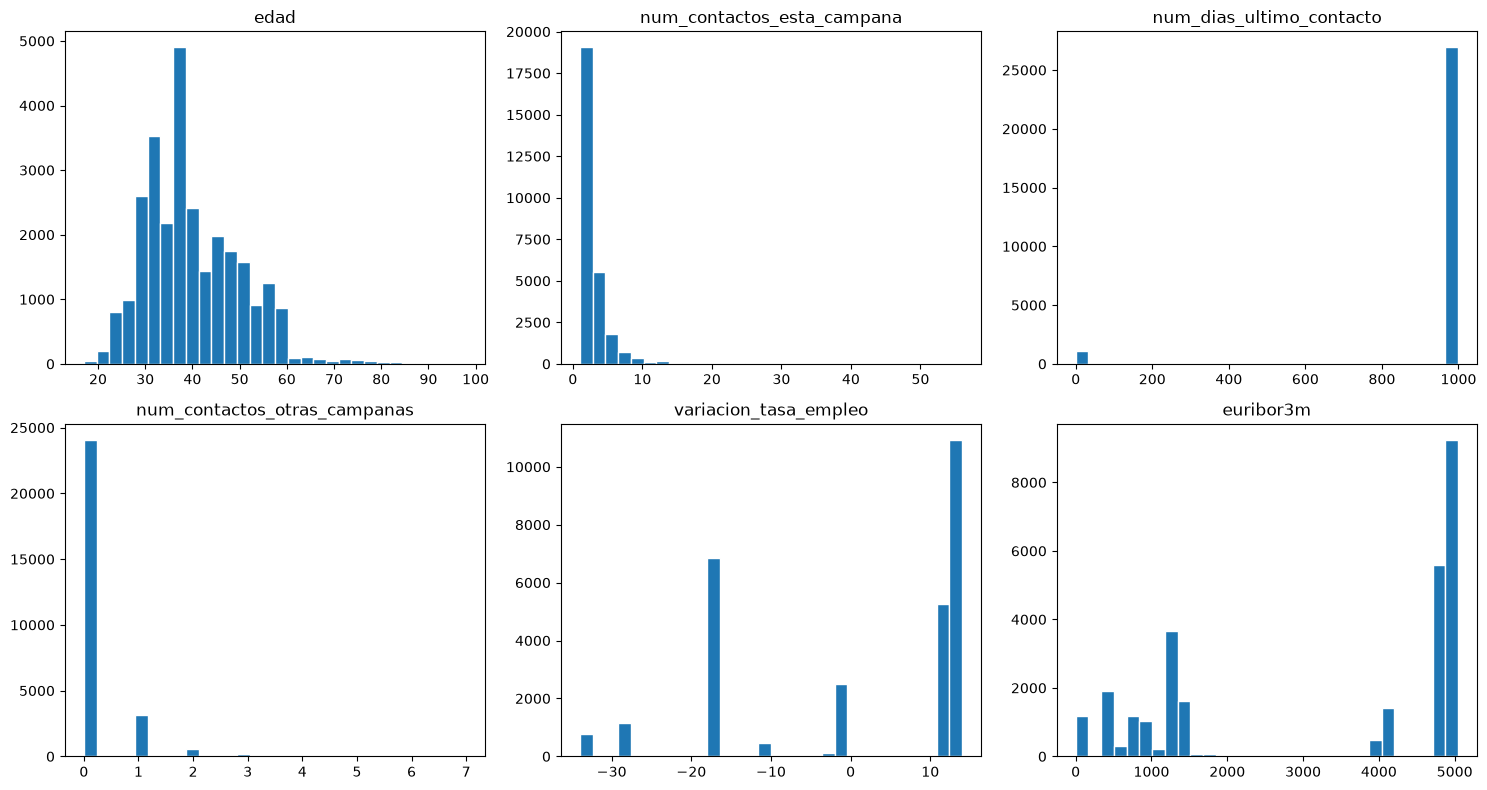

In [21]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 6 - Análisis univariante de numéricas
# ═══════════════════════════════════════════════════════════════════════

# ── 1. Estadísticos descriptivos (sin la variable objetivo) ───────────
NUMERICAS = ['edad', 'num_contactos_esta_campana', 'num_dias_ultimo_contacto',
             'num_contactos_otras_campanas', 'variacion_tasa_empleo', 'euribor3m']

stats = df[NUMERICAS].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
stats['std'] = df[NUMERICAS].std()
stats = stats[['mean', 'std', 'min', '1%', '5%', '25%', '50%', '75%', '95%', '99%', 'max']]
display(stats.round(2))
print()

# ── 2. Outliers por IQR ────────────────────────────────────────────────
print('── Detección de outliers por IQR (k=1.5) ──')
filas_iqr = []
for col in NUMERICAS:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = int(((df[col] < lim_inf) | (df[col] > lim_sup)).sum())
    filas_iqr.append({
        'columna': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'lim_inf': lim_inf, 'lim_sup': lim_sup,
        'n_outliers': n_out, '% outliers': round(100 * n_out / len(df), 2),
    })
tabla_iqr = pd.DataFrame(filas_iqr)
display(tabla_iqr.round(2))
print()

# ── 3. Histogramas ─────────────────────────────────────────────────────
fig, ejes = plt.subplots(2, 3, figsize=(15, 8))
ejes = ejes.flatten()
for i, col in enumerate(NUMERICAS):
    ejes[i].hist(df[col], bins=30, edgecolor='white')
    ejes[i].set_title(col)
plt.tight_layout()
plt.show()


In [22]:
# ── Aplicación de la propuesta de numéricas ───────────────────────────

# Convertir edad a int64 (todos los valores son enteros tras imputar con 38)
df['edad'] = df['edad'].astype('int64')

print('✅ edad convertida a int64')
print('✅ Sin winsorization/clipping (outliers = valores reales del dominio)')
print('✅ Centinela 999 de num_dias_ultimo_contacto conservado')
print('✅ Normalización diferida al modelado')
print()
print('Dtypes finales:')
print(df.dtypes)


✅ edad convertida a int64
✅ Sin winsorization/clipping (outliers = valores reales del dominio)
✅ Centinela 999 de num_dias_ultimo_contacto conservado
✅ Normalización diferida al modelado

Dtypes finales:
edad                               int64
trabajo                         category
estado_civil                    category
formacion                       category
impago                          category
prestamo_hipotecario            category
prestamo_personal               category
canal_de_contacto               category
mes                             category
num_contactos_esta_campana         int64
num_dias_ultimo_contacto           int64
num_contactos_otras_campanas       int64
resultado_campana_anterior      category
variacion_tasa_empleo              int64
euribor3m                          int64
contrata_fondos                    int64
dtype: object


In [23]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 7 - Columnas tipo ID
# ═══════════════════════════════════════════════════════════════════════

# ── Detección de columnas con cardinalidad ≈ nº de filas ──────────────
card = pd.DataFrame({
    'columna': df.columns,
    'unicos': [df[c].nunique() for c in df.columns],
    'n_filas': len(df),
    'cardinalidad_%': [round(100 * df[c].nunique() / len(df), 2) for c in df.columns],
    'dtype': df.dtypes.astype(str).values,
})
card['posible_id'] = card['cardinalidad_%'] > 90
display(card)

print()
print('── Candidatas a ID (cardinalidad > 90%) ──')
candidatas = card[card['posible_id']]
if candidatas.empty:
    print('   Ninguna columna tiene cardinalidad próxima al nº de filas.')
    print('   → No hay columnas tipo ID en el dataframe.')
else:
    display(candidatas)

print()
print('── El índice como identificador ──')
print(f'   Índice único tras reset: {df.index.is_unique} | '
      f'rango 0–{df.index.max()} ({len(df)} filas)')


,columna,unicos,n_filas,cardinalidad_%,dtype,posible_id
0,edad,78,28015,0.280,int64,False
1,trabajo,12,28015,0.040,category,False
2,estado_civil,4,28015,0.010,category,False
3,formacion,8,28015,0.030,category,False
4,impago,3,28015,0.010,category,False
5,prestamo_hipotecario,3,28015,0.010,category,False
6,prestamo_personal,3,28015,0.010,category,False
7,canal_de_contacto,2,28015,0.010,category,False
8,mes,10,28015,0.040,category,False
9,num_contactos_esta_campana,40,28015,0.140,int64,False



── Candidatas a ID (cardinalidad > 90%) ──
   Ninguna columna tiene cardinalidad próxima al nº de filas.
   → No hay columnas tipo ID en el dataframe.

── El índice como identificador ──
   Índice único tras reset: True | rango 0–28014 (28015 filas)


In [24]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 8 - Reglas lógicas dinámicas
# ═══════════════════════════════════════════════════════════════════════

# ── H1: sin contacto previo (999) ⇒ resultado_campana_anterior=nonexistent
h1 = df[(df['num_dias_ultimo_contacto'] == 999) &
        (df['resultado_campana_anterior'] != 'nonexistent')]
print(f'H1: 999 días (sin contacto previo) con resultado no "nonexistent": {len(h1)} violaciones')

# ── H2: con contacto previo (≠999) ⇒ resultado no "nonexistent"
h2 = df[(df['num_dias_ultimo_contacto'] != 999) &
        (df['resultado_campana_anterior'] == 'nonexistent')]
print(f'H2: con contacto previo pero resultado "nonexistent": {len(h2)} violaciones')

# ── H3: euribor3m y variacion_tasa_empleo constantes por mes
print()
print('H3: ¿euribor3m y variacion_tasa_empleo son constantes dentro de cada mes?')
indicadores = df.groupby('mes')[['euribor3m', 'variacion_tasa_empleo']].nunique()
display(indicadores)

# ── H4: edad fuera de rango razonable (18–100)
h4a = df[df['edad'] < 18]
h4b = df[df['edad'] > 100]
print(f'H4: edad < 18: {len(h4a)} | edad > 100: {len(h4b)}')
print('   Edades < 18 por trabajo:', h4a['trabajo'].value_counts().to_dict() if len(h4a) else 'ninguna')

# ── H5: num_contactos_esta_campana debe ser ≥ 1
h5 = df[df['num_contactos_esta_campana'] < 1]
print(f'H5: num_contactos_esta_campana < 1: {len(h5)} violaciones')


H1: 999 días (sin contacto previo) con resultado no "nonexistent": 2863 violaciones
H2: con contacto previo pero resultado "nonexistent": 0 violaciones

H3: ¿euribor3m y variacion_tasa_empleo son constantes dentro de cada mes?


,euribor3m,variacion_tasa_empleo
mes,,
apr,28,1
aug,39,3
dec,19,2
jul,49,3
jun,44,3
mar,36,1
may,35,2
nov,38,3
oct,48,3


H4: edad < 18: 3 | edad > 100: 0
   Edades < 18 por trabajo: {'student': 3, 'admin.': 0, 'blue-collar': 0, 'entrepreneur': 0, 'housemaid': 0, 'management': 0, 'retired': 0, 'self-employed': 0, 'services': 0, 'technician': 0, 'unemployed': 0, 'unknown': 0}
H5: num_contactos_esta_campana < 1: 0 violaciones


In [25]:
# ── Investigación de la relación num_dias vs resultado anterior ───────
print('── Tabla cruzada: num_dias==999 vs resultado_campana_anterior ──')
df['sin_contacto_previo'] = (df['num_dias_ultimo_contacto'] == 999).map({True: '999 (sin contacto)', False: '<999 (con contacto)'})
cruzada = pd.crosstab(df['sin_contacto_previo'], df['resultado_campana_anterior'], margins=True)
display(cruzada)
print()

# Valores no-999: ¿qué resultado tienen?
print('── Distribución de num_dias cuando ≠ 999 ──')
no999 = df[df['num_dias_ultimo_contacto'] != 999]
print('   Rango:', no999['num_dias_ultimo_contacto'].min(), 'a', no999['num_dias_ultimo_contacto'].max())
print('   Resultado:', no999['resultado_campana_anterior'].value_counts().to_dict())


── Tabla cruzada: num_dias==999 vs resultado_campana_anterior ──


resultado_campana_anterior,failure,nonexistent,success,All
sin_contacto_previo,,,,
999 (sin contacto),2863,24086,0,26949
<999 (con contacto),104,0,962,1066
All,2967,24086,962,28015



── Distribución de num_dias cuando ≠ 999 ──
   Rango: 0 a 27
   Resultado: {'success': 962, 'failure': 104, 'nonexistent': 0}


In [26]:
# ═══════════════════════════════════════════════════════════════════════
# TAREA 9 - Análisis adicionales automáticos
# ═══════════════════════════════════════════════════════════════════════

# ── 1. Balance de la variable objetivo ─────────────────────────────────
print('── Balance de contrata_fondos (target) ──')
balance = df['contrata_fondos'].value_counts().rename_axis('clase').reset_index(name='frecuencia')
balance['%'] = (100 * balance['frecuencia'] / len(df)).round(2)
display(balance)
print()

# ── 2. Ceros sospechosos en columnas numéricas ─────────────────────────
print('── Ceros en columnas numéricas ──')
for col in ['num_contactos_esta_campana', 'num_dias_ultimo_contacto',
            'num_contactos_otras_campanas', 'variacion_tasa_empleo', 'euribor3m']:
    n_ceros = (df[col] == 0).sum()
    print(f'   {col}: {n_ceros} ceros ({100 * n_ceros / len(df):.2f}%)')
print()

# ── 3. Columnas casi constantes (poca varianza) ────────────────────────
print('── Columnas con un solo valor dominante (>95%) ──')
for col in df.select_dtypes(include=['number']).columns:
    moda_pct = 100 * df[col].value_counts(normalize=True).iloc[0]
    if moda_pct > 95:
        print(f'   ⚠️ {col}: el valor {df[col].mode()[0]} aparece en {moda_pct:.2f}%')
print('   (sin avisos = sin columnas casi constantes)')
print()

# ── 4. Valores extremos únicos por columna numérica ────────────────────
print('── Valores extremos (min y max) por columna ──')
extremos = df[['num_contactos_esta_campana', 'num_contactos_otras_campanas',
               'variacion_tasa_empleo', 'euribor3m']].agg(['min', 'max']).T
display(extremos)


── Balance de contrata_fondos (target) ──


,clase,frecuencia,%
0,0,24781,88.460
1,1,3234,11.540



── Ceros en columnas numéricas ──
   num_contactos_esta_campana: 0 ceros (0.00%)
   num_dias_ultimo_contacto: 8 ceros (0.03%)
   num_contactos_otras_campanas: 24086 ceros (85.98%)
   variacion_tasa_empleo: 0 ceros (0.00%)
   euribor3m: 0 ceros (0.00%)

── Columnas con un solo valor dominante (>95%) ──
   ⚠️ num_dias_ultimo_contacto: el valor 999 aparece en 96.19%
   (sin avisos = sin columnas casi constantes)

── Valores extremos (min y max) por columna ──


,min,max
num_contactos_esta_campana,1,56
num_contactos_otras_campanas,0,7
variacion_tasa_empleo,-34,14
euribor3m,1,5045


In [27]:
# ═══════════════════════════════════════════════════════════════════════
# FASE 3 - FINALIZACIÓN
# ═══════════════════════════════════════════════════════════════════════

# ── 1. Guardar dataframe limpio ────────────────────────────────────────
ruta_limpio = ENTRENAMIENTO / '02_train_tablon_calidad.pkl'
df.to_pickle(ruta_limpio)
print(f'✅ Dataframe limpio guardado en: {ruta_limpio}')
print(f'   Shape final: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'   Nulos totales: {df.isna().sum().sum()}')
print()

# ── 2. Estructura final (para el informe y copilot-instructions) ──────
df.info()


✅ Dataframe limpio guardado en: c:\Users\Admin\Desktop\Desktop\CarpetaFisica\Data Detective\Ciencia_Datos_2\Caso_Agentes\02_datos\03_Entrenamiento\02_train_tablon_calidad.pkl
   Shape final: 28015 filas x 17 columnas
   Nulos totales: 0

<class 'pandas.DataFrame'>
RangeIndex: 28015 entries, 0 to 28014
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   edad                          28015 non-null  int64   
 1   trabajo                       28015 non-null  category
 2   estado_civil                  28015 non-null  category
 3   formacion                     28015 non-null  category
 4   impago                        28015 non-null  category
 5   prestamo_hipotecario          28015 non-null  category
 6   prestamo_personal             28015 non-null  category
 7   canal_de_contacto             28015 non-null  category
 8   mes                           28015 non-null  category
 9  

In [28]:
# ── Corrección: eliminar columna temporal de análisis ─────────────────
# 'sin_contacto_previo' se creó solo para la TAREA 8, no es una
# característica real del tablón
if 'sin_contacto_previo' in df.columns:
    df = df.drop(columns=['sin_contacto_previo'])
    print('✅ Columna temporal sin_contacto_previo eliminada')
else:
    print('ℹ️ sin_contacto_previo no presente')

# ── Reguardar el dataframe limpio ──────────────────────────────────────
df.to_pickle(ruta_limpio)
print(f'✅ Dataframe limpio reguardado: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'   Nulos totales: {df.isna().sum().sum()}')
print()
df.info()


✅ Columna temporal sin_contacto_previo eliminada
✅ Dataframe limpio reguardado: 28015 filas x 16 columnas
   Nulos totales: 0

<class 'pandas.DataFrame'>
RangeIndex: 28015 entries, 0 to 28014
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   edad                          28015 non-null  int64   
 1   trabajo                       28015 non-null  category
 2   estado_civil                  28015 non-null  category
 3   formacion                     28015 non-null  category
 4   impago                        28015 non-null  category
 5   prestamo_hipotecario          28015 non-null  category
 6   prestamo_personal             28015 non-null  category
 7   canal_de_contacto             28015 non-null  category
 8   mes                           28015 non-null  category
 9   num_contactos_esta_campana    28015 non-null  int64   
 10  num_dias_ultimo_contacto      28015 non-null  int6